In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
test = pd.read_csv('/kaggle/input/linear-regression-winter-2024-airbnb-prices/test_regression.csv')
test.head()

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1034230914292810598,760775794,2020-12-16,NaN,within a day,88%,80%,f,Near West Side,44,44,"['email', 'phone']",t,t,Lincoln Park,41.931102,-87.667468,Entire rental unit,Entire home/apt,14,1 bath,1.0,32,730,32,32,730,730,32.0,730.0,t,30,60,90,365,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,44,2,42,0,NaN
1,26579870,214868994,2016-12-16,"New York, NY",within an hour,100%,97%,f,Cambridge,4820,6438,"['email', 'phone', 'work_email']",t,t,Near North Side,41.891162,-87.622263,Entire rental unit,Entire home/apt,2,1 bath,1.0,32,1125,32,366,1125,1125,354.2,1125.0,t,0,1,31,306,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,643,643,0,0,NaN
2,27063669,497520971,2019-03-14,NaN,within an hour,99%,99%,t,West Loop/Greektown,71,88,['phone'],t,t,Near North Side,41.895350,-87.626040,Entire rental unit,Entire home/apt,8,2 baths,3.0,3,344,2,3,1125,1125,2.2,1125.0,t,20,47,77,344,11,11,2,2023-05-28,2023-12-02,4.73,4.91,5.00,4.82,4.91,4.91,4.64,t,51,51,0,0,1.61
3,21423682,48776231,2014-12-02,"Chicago, IL",within an hour,100%,100%,t,Streeterville,14,47,"['email', 'phone']",t,t,Near North Side,41.891376,-87.620269,Entire rental unit,Entire home/apt,4,1 bath,1.0,32,1125,32,32,1125,1125,32.0,1125.0,t,30,60,90,365,6,2,0,2021-05-04,2023-08-02,4.67,5.00,5.00,4.67,4.83,5.00,4.67,f,14,14,0,0,0.19
4,633433690826539871,514928878,2019-04-22,NaN,within a day,100%,65%,f,River North,20,22,"['email', 'phone']",t,t,Near North Side,41.894760,-87.625640,Entire condo,Entire home/apt,3,1 bath,1.0,32,365,32,32,365,365,32.0,365.0,t,0,15,45,45,3,1,0,2022-06-03,2023-05-03,4.67,4.00,4.67,4.67,4.67,5.00,4.67,f,19,19,0,0,0.16


In [3]:
train = pd.read_csv('/kaggle/input/linear-regression-winter-2024-airbnb-prices/train_regression.csv')
train.head()

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,26774767,366516391,2018-04-09,"Chicago, IL",within an hour,96%,95%,f,Back of the Yards,11,13,"['email', 'phone']",t,t,New City,41.794240,-87.661380,Private room in rental unit,Private room,1,1 shared bath,1.0,$30.00,32,1125,32,32,1125,1125,32.0,1125.0,t,30,60,90,365,18,0,0,2019-06-16,2022-08-12,4.94,5.00,4.89,5.00,5.00,4.28,4.83,f,9,1,8,0,0.33
1,775792777857790668,50276775,2014-12-23,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,2346,"['email', 'phone']",t,t,Near North Side,41.892749,-87.620711,Room in hotel,Private room,12,3 baths,3.0,"$1,247.00",32,365,32,32,365,365,32.0,365.0,t,25,49,66,135,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,58,0,58,0,NaN
2,33948525,681680651,2020-03-08,NaN,within an hour,100%,100%,f,Lake View East,1,1,['phone'],t,t,Lake View,41.948160,-87.652309,Entire rental unit,Entire home/apt,6,1 bath,3.0,$214.00,2,45,2,2,45,45,2.0,45.0,t,0,0,0,0,14,14,1,2023-07-21,2023-12-03,4.87,5.00,5.00,5.00,5.00,4.93,4.80,f,1,1,0,0,2.78
3,569476879862677256,94345291,2015-10-22,"Chicago, IL",within an hour,100%,98%,f,Bucktown,55,58,"['email', 'phone', 'work_email']",t,t,Hyde Park,41.801030,-87.597160,Entire rental unit,Entire home/apt,2,1 bath,1.0,$59.00,2,180,2,2,180,180,2.0,180.0,t,23,53,83,355,13,13,3,2023-09-02,2023-12-06,4.08,4.08,4.00,4.38,4.23,4.54,3.85,t,55,55,0,0,3.61
4,36537053,790998106,2021-04-04,"Chicago, IL",within an hour,100%,100%,t,Near South Side,74,75,"['email', 'phone']",t,t,Near South Side,41.855770,-87.624130,Entire rental unit,Entire home/apt,6,2 baths,3.0,$151.00,2,365,2,2,1125,1125,2.0,1125.0,t,0,0,0,0,64,42,3,2022-05-06,2023-12-06,4.80,4.74,4.75,4.83,4.85,4.74,4.72,t,74,74,0,0,3.24


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,26774767,366516391,2018-04-09,"Chicago, IL",within an hour,96%,95%,f,Back of the Yards,11,13,"['email', 'phone']",t,t,New City,41.794240,-87.661380,Private room in rental unit,Private room,1,1 shared bath,1.0,$30.00,32,1125,32,32,1125,1125,32.0,1125.0,t,30,60,90,365,18,0,0,2019-06-16,2022-08-12,4.94,5.00,4.89,5.00,5.00,4.28,4.83,f,9,1,8,0,0.33
1,775792777857790668,50276775,2014-12-23,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,2346,"['email', 'phone']",t,t,Near North Side,41.892749,-87.620711,Room in hotel,Private room,12,3 baths,3.0,"$1,247.00",32,365,32,32,365,365,32.0,365.0,t,25,49,66,135,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,58,0,58,0,NaN
2,33948525,681680651,2020-03-08,NaN,within an hour,100%,100%,f,Lake View East,1,1,['phone'],t,t,Lake View,41.948160,-87.652309,Entire rental unit,Entire home/apt,6,1 bath,3.0,$214.00,2,45,2,2,45,45,2.0,45.0,t,0,0,0,0,14,14,1,2023-07-21,2023-12-03,4.87,5.00,5.00,5.00,5.00,4.93,4.80,f,1,1,0,0,2.78
3,569476879862677256,94345291,2015-10-22,"Chicago, IL",within an hour,100%,98%,f,Bucktown,55,58,"['email', 'phone', 'work_email']",t,t,Hyde Park,41.801030,-87.597160,Entire rental unit,Entire home/apt,2,1 bath,1.0,$59.00,2,180,2,2,180,180,2.0,180.0,t,23,53,83,355,13,13,3,2023-09-02,2023-12-06,4.08,4.08,4.00,4.38,4.23,4.54,3.85,t,55,55,0,0,3.61
4,36537053,790998106,2021-04-04,"Chicago, IL",within an hour,100%,100%,t,Near South Side,74,75,"['email', 'phone']",t,t,Near South Side,41.855770,-87.624130,Entire rental unit,Entire home/apt,6,2 baths,3.0,$151.00,2,365,2,2,1125,1125,2.0,1125.0,t,0,0,0,0,64,42,3,2022-05-06,2023-12-06,4.80,4.74,4.75,4.83,4.85,4.74,4.72,t,74,74,0,0,3.24


In [5]:
combined.dtypes

id                                                int64
host_id                                           int64
host_since                                       object
host_location                                    object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                             object
host_is_superhost                                object
host_neighbourhood                               object
host_listings_count                               int64
host_total_listings_count                         int64
host_verifications                               object
host_has_profile_pic                             object
host_identity_verified                           object
neighbourhood_cleansed                           object
latitude                                        float64
longitude                                       float64
property_type                                   

In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8338 entries, 0 to 3337
Data columns (total 54 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            8338 non-null   int64  
 1   host_id                                       8338 non-null   int64  
 2   host_since                                    8338 non-null   object 
 3   host_location                                 6742 non-null   object 
 4   host_response_time                            7618 non-null   object 
 5   host_response_rate                            7618 non-null   object 
 6   host_acceptance_rate                          7847 non-null   object 
 7   host_is_superhost                             8301 non-null   object 
 8   host_neighbourhood                            8102 non-null   object 
 9   host_listings_count                           8338 non-null   int64 

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,8338.0,4.333793e+17,4.242591e+17,2384.000000,3.928850e+07,5.828907e+17,8.529155e+17,1.048046e+18
host_id,8338.0,3.722326e+08,3.435440e+08,4454.000000,7.225669e+07,2.225740e+08,6.766380e+08,1.098756e+09
host_listings_count,8338.0,4.046451e+02,1.273801e+03,1.000000,1.000000e+00,5.000000e+00,2.300000e+01,4.820000e+03
host_total_listings_count,8338.0,5.720479e+02,1.777565e+03,1.000000,2.000000e+00,7.000000e+00,3.200000e+01,8.868000e+03
latitude,8338.0,4.189169e+01,6.286654e-02,41.646767,4.185977e+01,4.189598e+01,4.193520e+01,4.202220e+01
longitude,8338.0,-8.766208e+01,4.439146e-02,-87.847243,-8.768547e+01,-8.765730e+01,-8.763025e+01,-8.752842e+01
accommodates,8338.0,4.368674e+00,3.066194e+00,1.000000,2.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01
beds,8271.0,2.277596e+00,1.735769e+00,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,2.400000e+01
minimum_nights,8338.0,1.534481e+01,4.223370e+01,1.000000,2.000000e+00,2.000000e+00,3.200000e+01,1.125000e+03
maximum_nights,8338.0,5.564705e+02,4.444033e+02,1.000000,1.500000e+02,3.650000e+02,1.125000e+03,1.125000e+03


In [8]:
combined.columns

Index(['id', 'host_id', 'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'r

In [9]:
combined.isnull().notnull()/len(combined*100)

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
1,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
2,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
3,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
4,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012
3334,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0.00012,0

In [10]:
combined.shape

(8338, 54)

In [11]:
cat_cols = combined.select_dtypes(include='object')

In [12]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)
    

host_since
__________________________________________________
host_location
__________________________________________________
host_response_time
__________________________________________________
host_response_rate
__________________________________________________
host_acceptance_rate
__________________________________________________
host_is_superhost
__________________________________________________
host_neighbourhood
__________________________________________________
host_verifications
__________________________________________________
host_has_profile_pic
__________________________________________________
host_identity_verified
__________________________________________________
neighbourhood_cleansed
__________________________________________________
property_type
__________________________________________________
room_type
__________________________________________________
bathrooms_text
__________________________________________________
price
__________________________________

In [13]:
num_cols = combined.select_dtypes(include='number')

In [14]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

id
__________________________________________________
host_id
__________________________________________________
host_listings_count
__________________________________________________
host_total_listings_count
__________________________________________________
latitude
__________________________________________________
longitude
__________________________________________________
accommodates
__________________________________________________
beds
__________________________________________________
minimum_nights
__________________________________________________
maximum_nights
__________________________________________________
minimum_minimum_nights
__________________________________________________
maximum_minimum_nights
__________________________________________________
minimum_maximum_nights
__________________________________________________
maximum_maximum_nights
__________________________________________________
minimum_nights_avg_ntm
_______________________________________________

<Axes: >

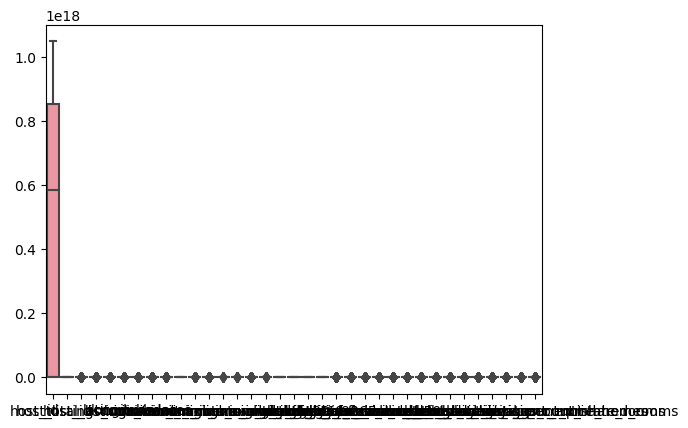

In [15]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


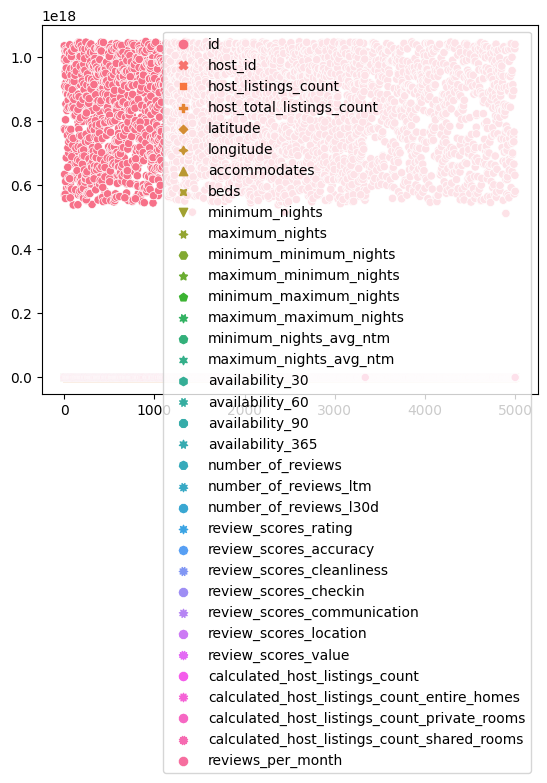

In [16]:
sns.scatterplot(combined)

<Axes: >

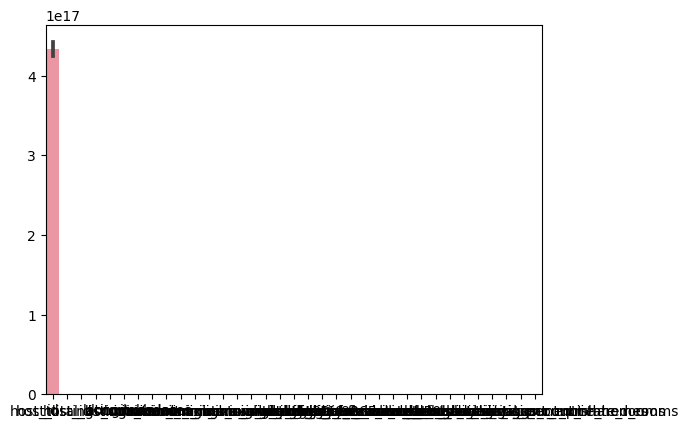

In [17]:
sns.barplot(combined)

<Axes: >

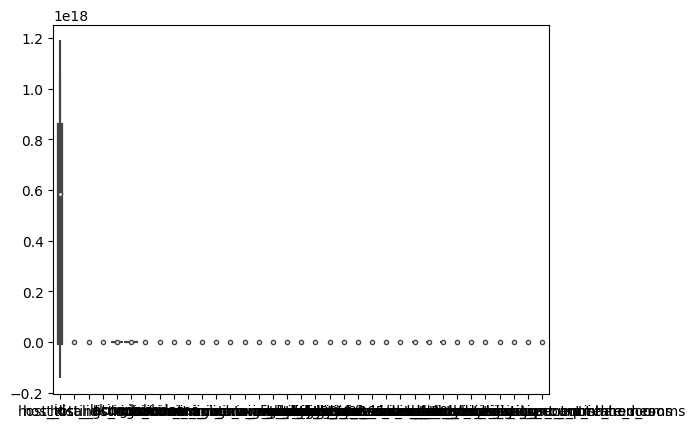

In [18]:
sns.violinplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

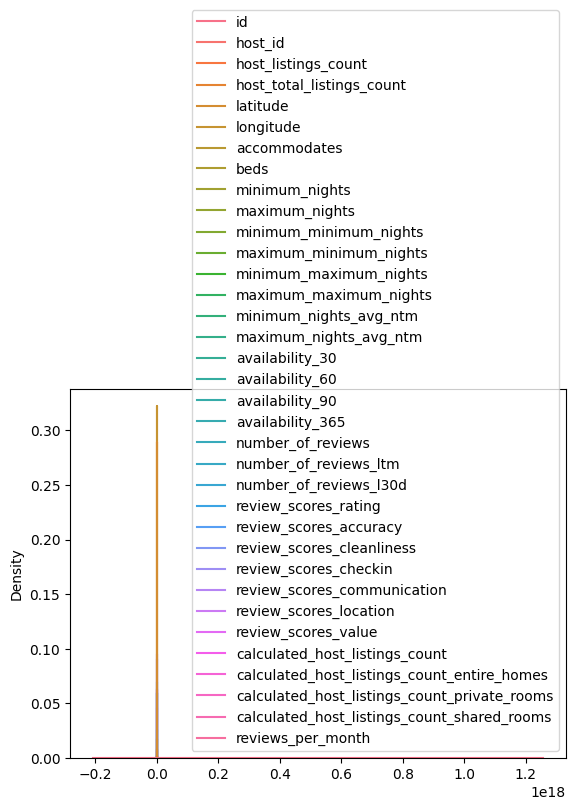

In [19]:
sns.kdeplot(combined)

In [20]:
combined.skew

<bound method DataFrame.skew of                       id    host_id  host_since host_location  \
0               26774767  366516391  2018-04-09   Chicago, IL   
1     775792777857790668   50276775  2014-12-23           NaN   
2               33948525  681680651  2020-03-08           NaN   
3     569476879862677256   94345291  2015-10-22   Chicago, IL   
4               36537053  790998106  2021-04-04   Chicago, IL   
...                  ...        ...         ...           ...   
3333            28864302  222125407  2017-01-12           NaN   
3334  941966459267198958   45217511  2014-10-16   Chicago, IL   
3335            40978910   23822019  2014-02-03   Chicago, IL   
3336            39088461  352458899  2018-03-02           NaN   
3337            53929336  125080843  2016-03-11   Chicago, IL   

     host_response_time host_response_rate host_acceptance_rate  \
0        within an hour                96%                  95%   
1        within an hour               100%           

In [21]:
combined.kurt

<bound method DataFrame.kurt of                       id    host_id  host_since host_location  \
0               26774767  366516391  2018-04-09   Chicago, IL   
1     775792777857790668   50276775  2014-12-23           NaN   
2               33948525  681680651  2020-03-08           NaN   
3     569476879862677256   94345291  2015-10-22   Chicago, IL   
4               36537053  790998106  2021-04-04   Chicago, IL   
...                  ...        ...         ...           ...   
3333            28864302  222125407  2017-01-12           NaN   
3334  941966459267198958   45217511  2014-10-16   Chicago, IL   
3335            40978910   23822019  2014-02-03   Chicago, IL   
3336            39088461  352458899  2018-03-02           NaN   
3337            53929336  125080843  2016-03-11   Chicago, IL   

     host_response_time host_response_rate host_acceptance_rate  \
0        within an hour                96%                  95%   
1        within an hour               100%           

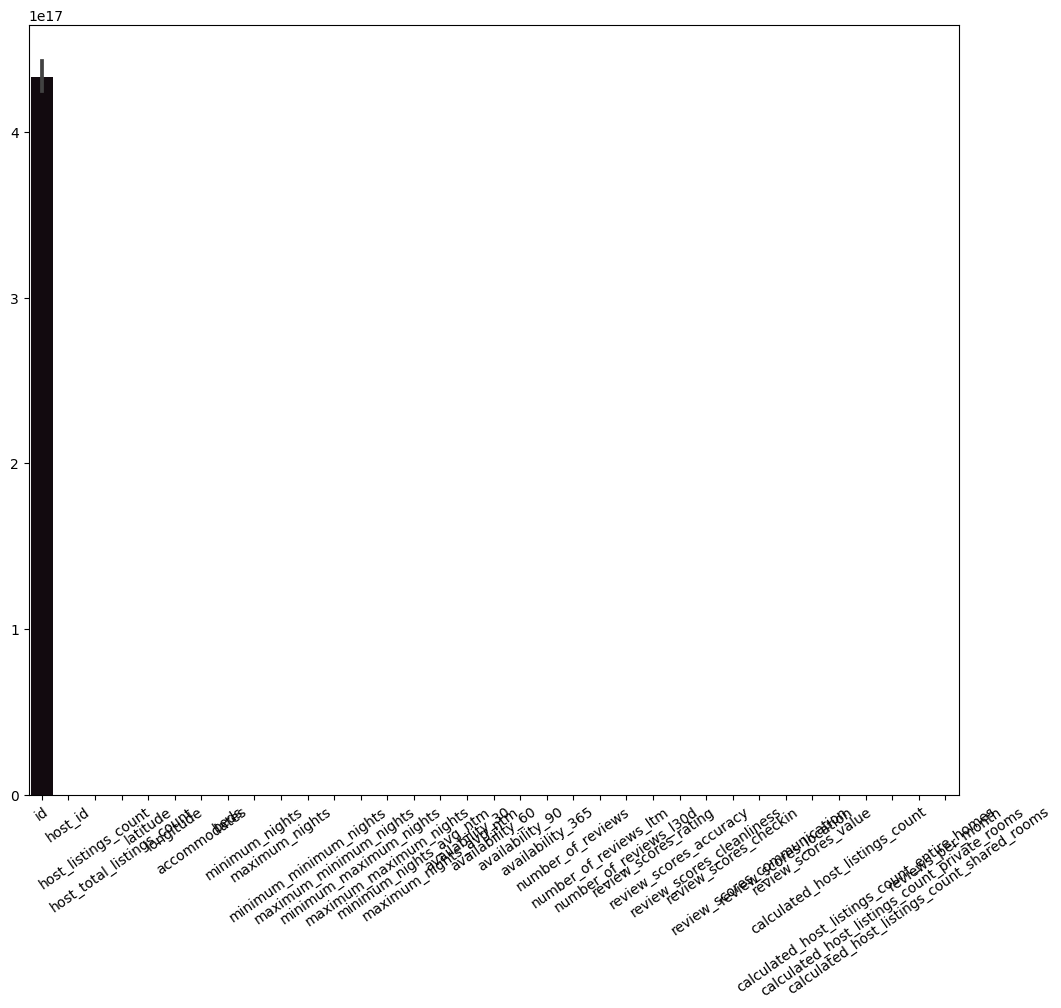

In [22]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


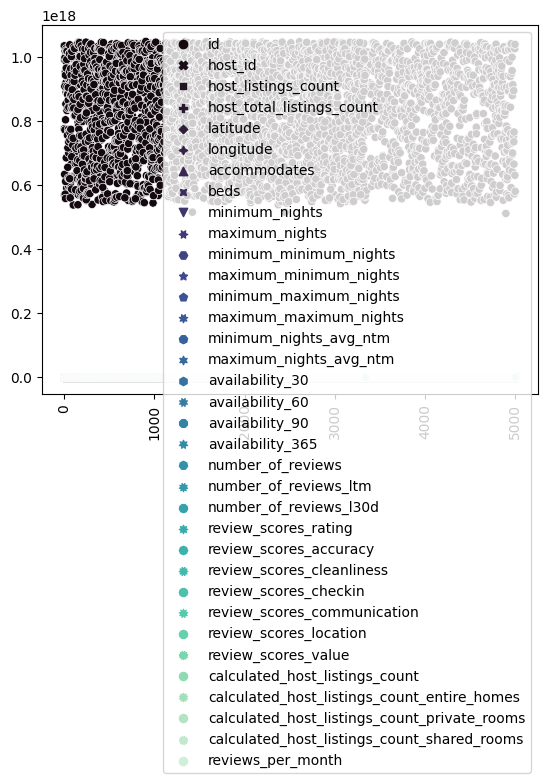

In [23]:
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

(array([-4.0e+17, -2.0e+17,  0.0e+00,  2.0e+17,  4.0e+17,  6.0e+17,
         8.0e+17,  1.0e+18,  1.2e+18,  1.4e+18]),
 [Text(-4e+17, 0, '−0.4'),
  Text(-2e+17, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(2e+17, 0, '0.2'),
  Text(4e+17, 0, '0.4'),
  Text(6e+17, 0, '0.6'),
  Text(8e+17, 0, '0.8'),
  Text(1e+18, 0, '1.0'),
  Text(1.2e+18, 0, '1.2'),
  Text(1.4e+18, 0, '1.4')])

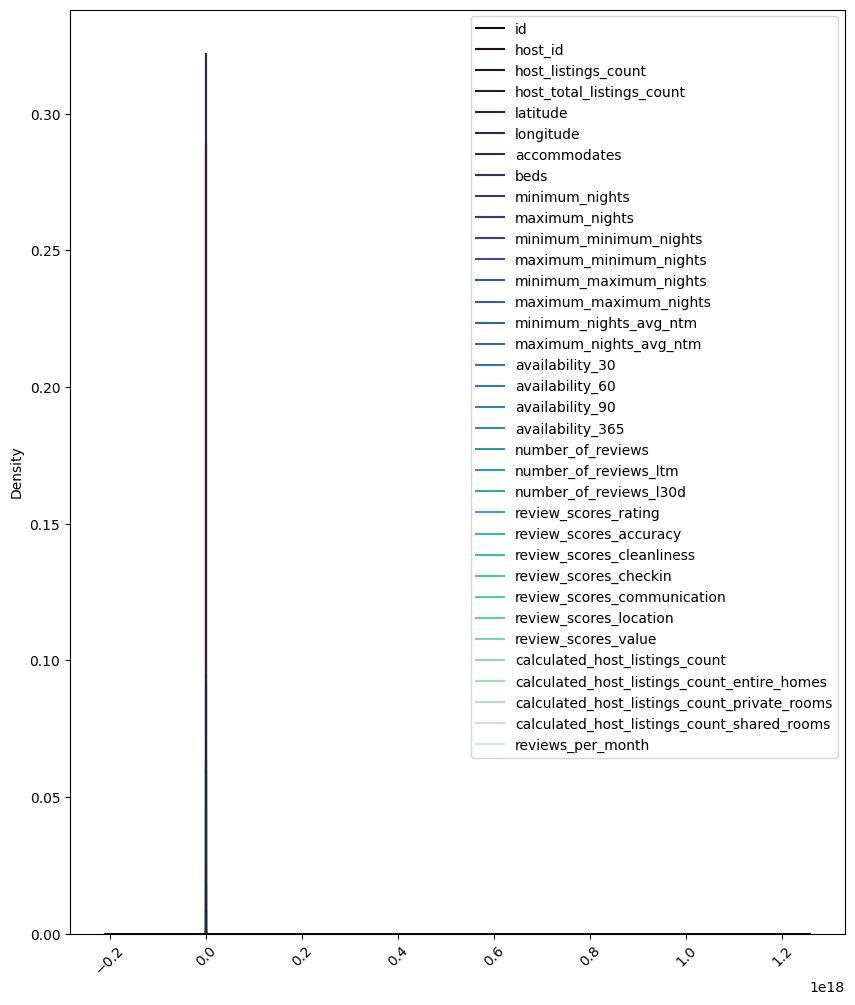

In [24]:
plt.figure(figsize=(10,12))
sns.kdeplot(data=combined,palette='mako')
plt.xticks(rotation=45)

In [25]:
combined.head()

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,26774767,366516391,2018-04-09,"Chicago, IL",within an hour,96%,95%,f,Back of the Yards,11,13,"['email', 'phone']",t,t,New City,41.794240,-87.661380,Private room in rental unit,Private room,1,1 shared bath,1.0,$30.00,32,1125,32,32,1125,1125,32.0,1125.0,t,30,60,90,365,18,0,0,2019-06-16,2022-08-12,4.94,5.00,4.89,5.00,5.00,4.28,4.83,f,9,1,8,0,0.33
1,775792777857790668,50276775,2014-12-23,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,2346,"['email', 'phone']",t,t,Near North Side,41.892749,-87.620711,Room in hotel,Private room,12,3 baths,3.0,"$1,247.00",32,365,32,32,365,365,32.0,365.0,t,25,49,66,135,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,58,0,58,0,NaN
2,33948525,681680651,2020-03-08,NaN,within an hour,100%,100%,f,Lake View East,1,1,['phone'],t,t,Lake View,41.948160,-87.652309,Entire rental unit,Entire home/apt,6,1 bath,3.0,$214.00,2,45,2,2,45,45,2.0,45.0,t,0,0,0,0,14,14,1,2023-07-21,2023-12-03,4.87,5.00,5.00,5.00,5.00,4.93,4.80,f,1,1,0,0,2.78
3,569476879862677256,94345291,2015-10-22,"Chicago, IL",within an hour,100%,98%,f,Bucktown,55,58,"['email', 'phone', 'work_email']",t,t,Hyde Park,41.801030,-87.597160,Entire rental unit,Entire home/apt,2,1 bath,1.0,$59.00,2,180,2,2,180,180,2.0,180.0,t,23,53,83,355,13,13,3,2023-09-02,2023-12-06,4.08,4.08,4.00,4.38,4.23,4.54,3.85,t,55,55,0,0,3.61
4,36537053,790998106,2021-04-04,"Chicago, IL",within an hour,100%,100%,t,Near South Side,74,75,"['email', 'phone']",t,t,Near South Side,41.855770,-87.624130,Entire rental unit,Entire home/apt,6,2 baths,3.0,$151.00,2,365,2,2,1125,1125,2.0,1125.0,t,0,0,0,0,64,42,3,2022-05-06,2023-12-06,4.80,4.74,4.75,4.83,4.85,4.74,4.72,t,74,74,0,0,3.24


In [26]:
combined['id'].value_counts()

id
26774767              1
741628256931082742    1
53423379              1
558811956702505421    1
47550424              1
                     ..
50216087              1
21860008              1
34195425              1
868699840020024260    1
53929336              1
Name: count, Length: 8338, dtype: int64

In [27]:
combined.mean

<bound method DataFrame.mean of                       id    host_id  host_since host_location  \
0               26774767  366516391  2018-04-09   Chicago, IL   
1     775792777857790668   50276775  2014-12-23           NaN   
2               33948525  681680651  2020-03-08           NaN   
3     569476879862677256   94345291  2015-10-22   Chicago, IL   
4               36537053  790998106  2021-04-04   Chicago, IL   
...                  ...        ...         ...           ...   
3333            28864302  222125407  2017-01-12           NaN   
3334  941966459267198958   45217511  2014-10-16   Chicago, IL   
3335            40978910   23822019  2014-02-03   Chicago, IL   
3336            39088461  352458899  2018-03-02           NaN   
3337            53929336  125080843  2016-03-11   Chicago, IL   

     host_response_time host_response_rate host_acceptance_rate  \
0        within an hour                96%                  95%   
1        within an hour               100%           

In [28]:
combined['id'].mean()

4.333792808641836e+17

In [29]:
for column in combined.columns:
    if combined['id'].dtype == 'object':
        print(combined['id'].value_counts())

In [30]:
combined.head()

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,26774767,366516391,2018-04-09,"Chicago, IL",within an hour,96%,95%,f,Back of the Yards,11,13,"['email', 'phone']",t,t,New City,41.794240,-87.661380,Private room in rental unit,Private room,1,1 shared bath,1.0,$30.00,32,1125,32,32,1125,1125,32.0,1125.0,t,30,60,90,365,18,0,0,2019-06-16,2022-08-12,4.94,5.00,4.89,5.00,5.00,4.28,4.83,f,9,1,8,0,0.33
1,775792777857790668,50276775,2014-12-23,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,2346,"['email', 'phone']",t,t,Near North Side,41.892749,-87.620711,Room in hotel,Private room,12,3 baths,3.0,"$1,247.00",32,365,32,32,365,365,32.0,365.0,t,25,49,66,135,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,58,0,58,0,NaN
2,33948525,681680651,2020-03-08,NaN,within an hour,100%,100%,f,Lake View East,1,1,['phone'],t,t,Lake View,41.948160,-87.652309,Entire rental unit,Entire home/apt,6,1 bath,3.0,$214.00,2,45,2,2,45,45,2.0,45.0,t,0,0,0,0,14,14,1,2023-07-21,2023-12-03,4.87,5.00,5.00,5.00,5.00,4.93,4.80,f,1,1,0,0,2.78
3,569476879862677256,94345291,2015-10-22,"Chicago, IL",within an hour,100%,98%,f,Bucktown,55,58,"['email', 'phone', 'work_email']",t,t,Hyde Park,41.801030,-87.597160,Entire rental unit,Entire home/apt,2,1 bath,1.0,$59.00,2,180,2,2,180,180,2.0,180.0,t,23,53,83,355,13,13,3,2023-09-02,2023-12-06,4.08,4.08,4.00,4.38,4.23,4.54,3.85,t,55,55,0,0,3.61
4,36537053,790998106,2021-04-04,"Chicago, IL",within an hour,100%,100%,t,Near South Side,74,75,"['email', 'phone']",t,t,Near South Side,41.855770,-87.624130,Entire rental unit,Entire home/apt,6,2 baths,3.0,$151.00,2,365,2,2,1125,1125,2.0,1125.0,t,0,0,0,0,64,42,3,2022-05-06,2023-12-06,4.80,4.74,4.75,4.83,4.85,4.74,4.72,t,74,74,0,0,3.24


In [31]:
reviews_per_month = combined['reviews_per_month'].quantile(0.95)
print(f'The value under which 95% of the reviews_per_month would lie is: {reviews_per_month}')

The value under which 95% of the reviews_per_month would lie is: 4.726499999999996


In [32]:
most_common_education = combined['review_scores_value'].mode().values[0]
print(f'the most common qualification among individuals is : {most_common_education}')

the most common qualification among individuals is : 5.0


In [33]:
median_age_by_class = combined.groupby('number_of_reviews')['host_id'].median()
print('median age for different working')
print(median_age_by_class)

median age for different working
number_of_reviews
0       224459185.0
1       214868994.0
2       294733047.0
3       223035394.0
4       256531754.0
           ...     
845     177133870.0
860     103337102.0
1016    370042438.0
1542    114775867.0
3501    114775867.0
Name: host_id, Length: 426, dtype: float64


In [34]:
from scipy.stats import trim_mean
mean_capital_gain = combined['host_id'].mean()
trimmed_mean_capital_gain = trim_mean(combined['host_id'],proportiontocut=0.05)
print(f'mean of capital gain :{mean_capital_gain}')
print(f'Trimmed mean of capital_gain(5% trimmed): {trimmed_mean_capital_gain}')

mean of capital gain :372232557.5064764
Trimmed mean of capital_gain(5% trimmed): 355164978.2733813


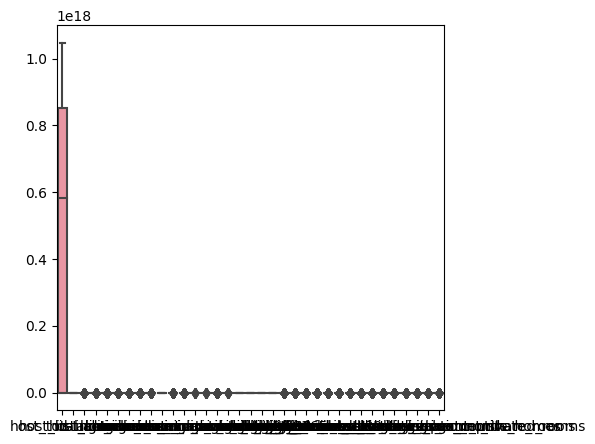

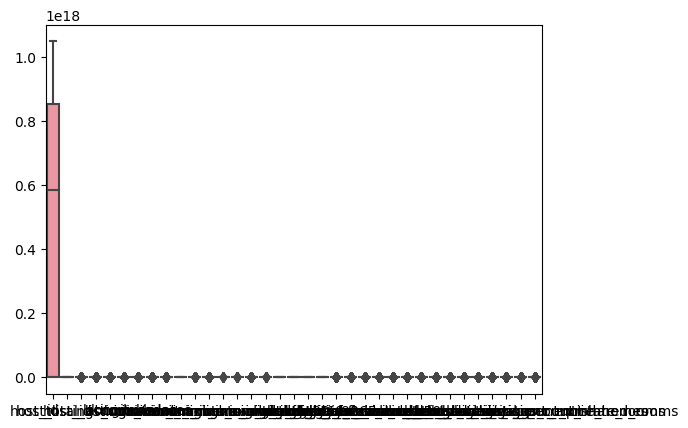

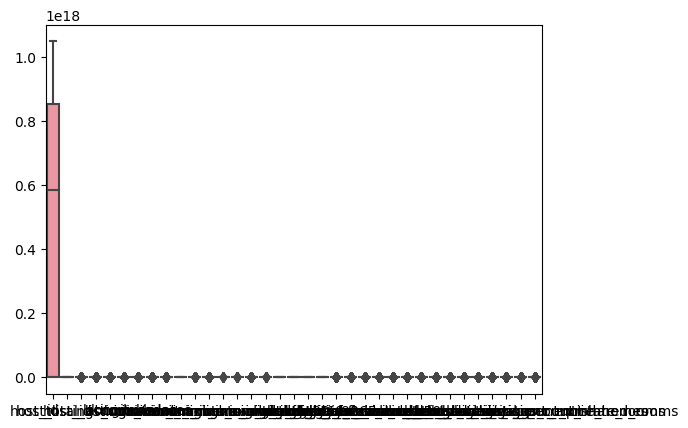

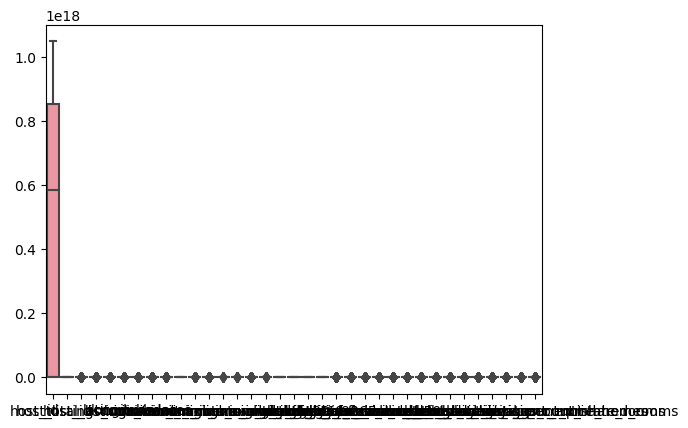

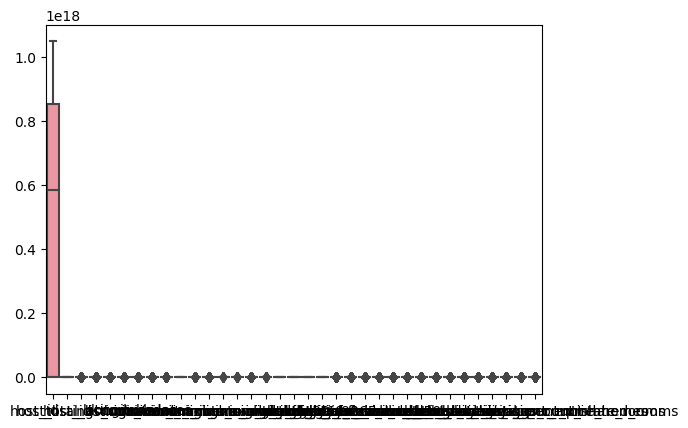

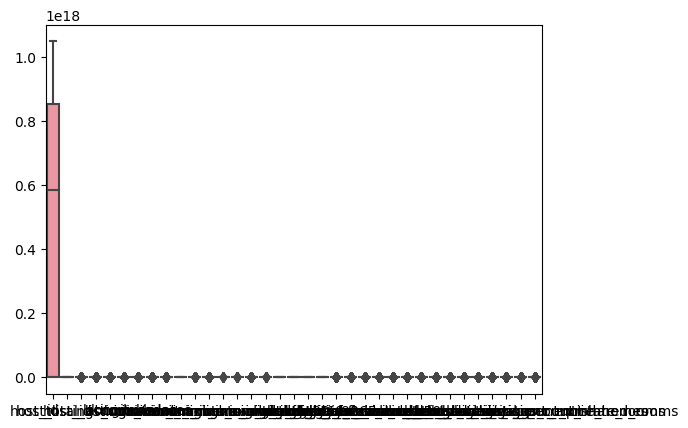

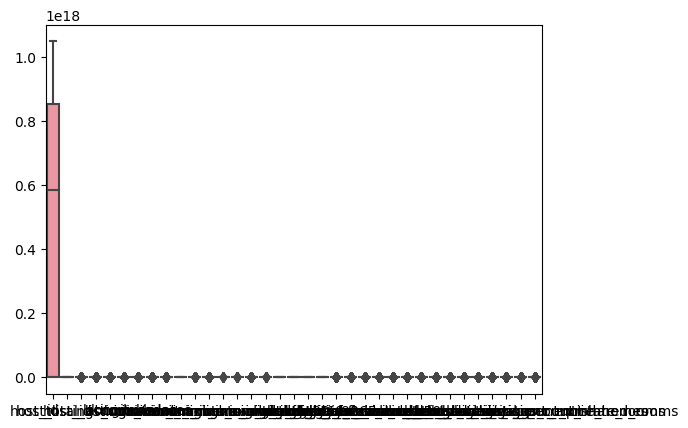

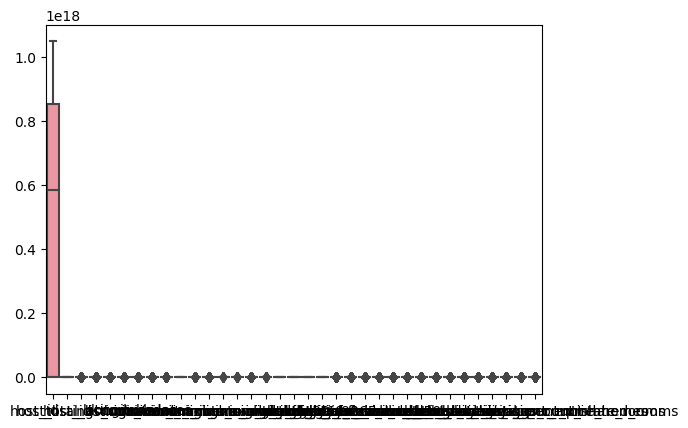

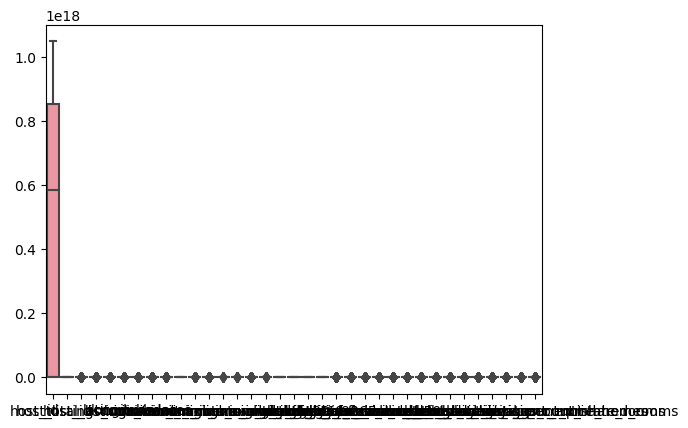

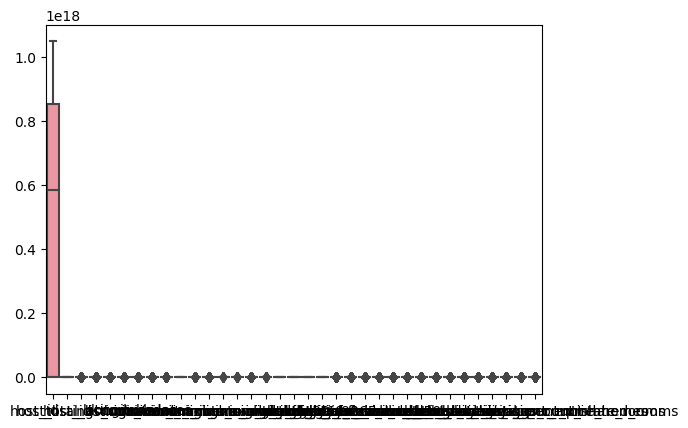

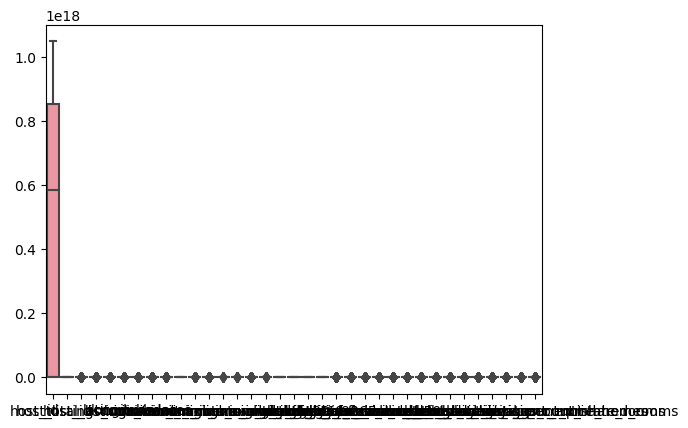

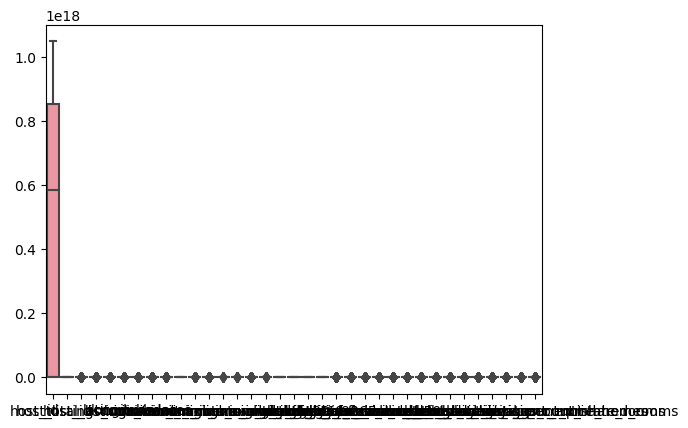

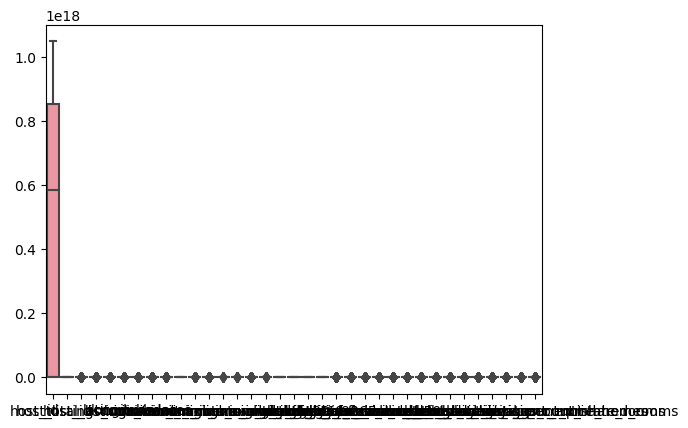

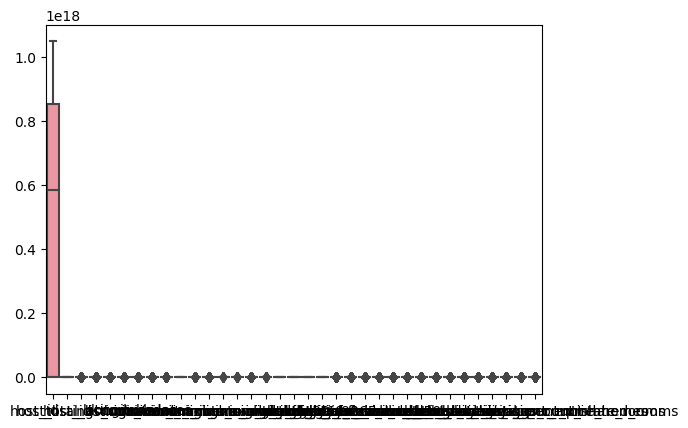

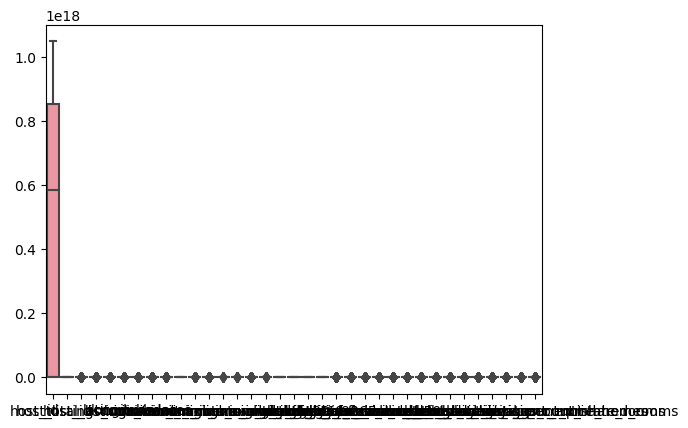

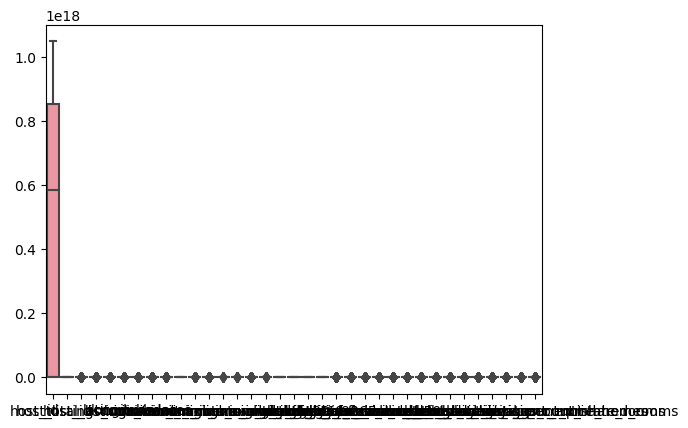

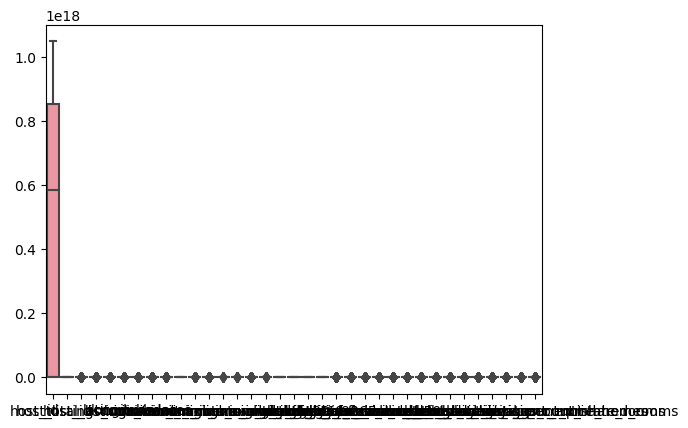

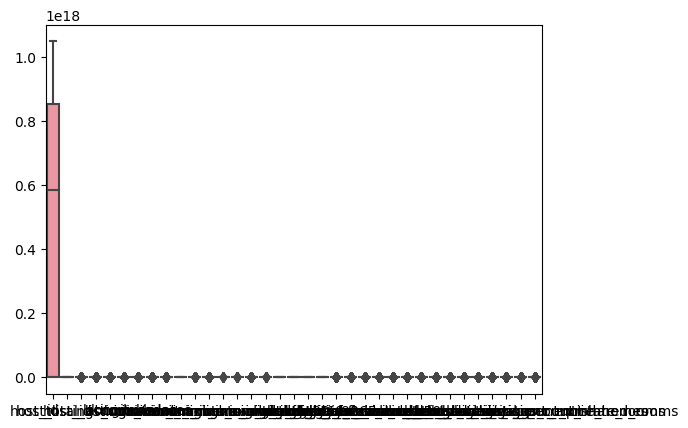

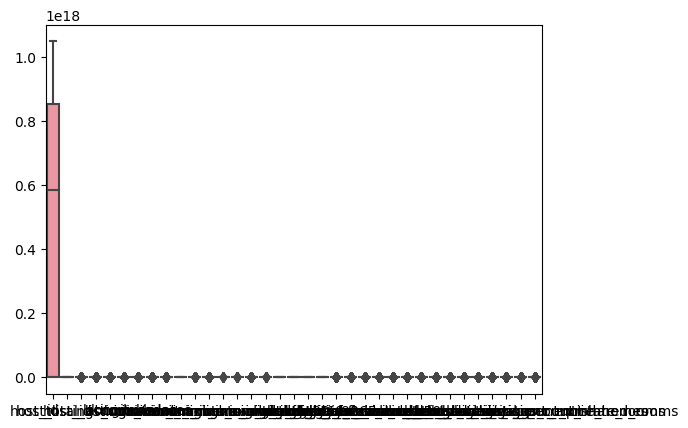

In [35]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.boxplot(combined)
    print('\n')
    plt.show()
    

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

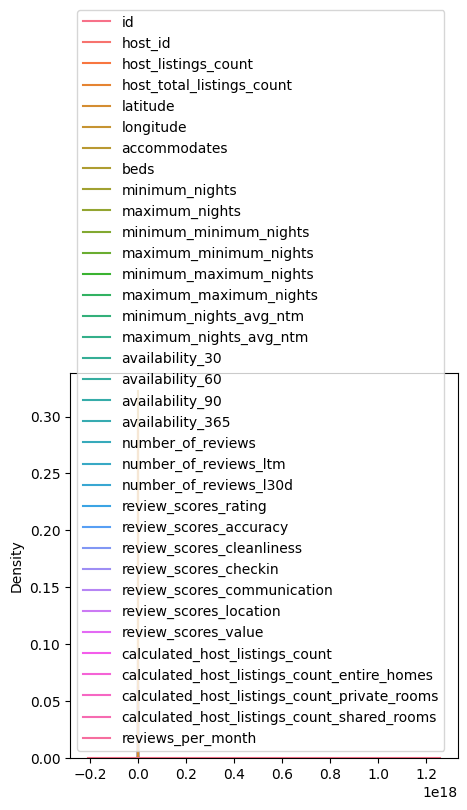

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

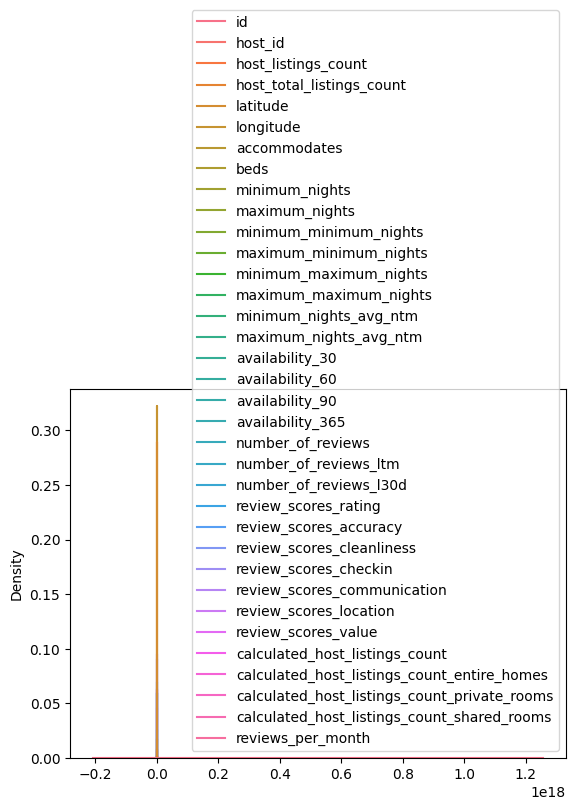

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

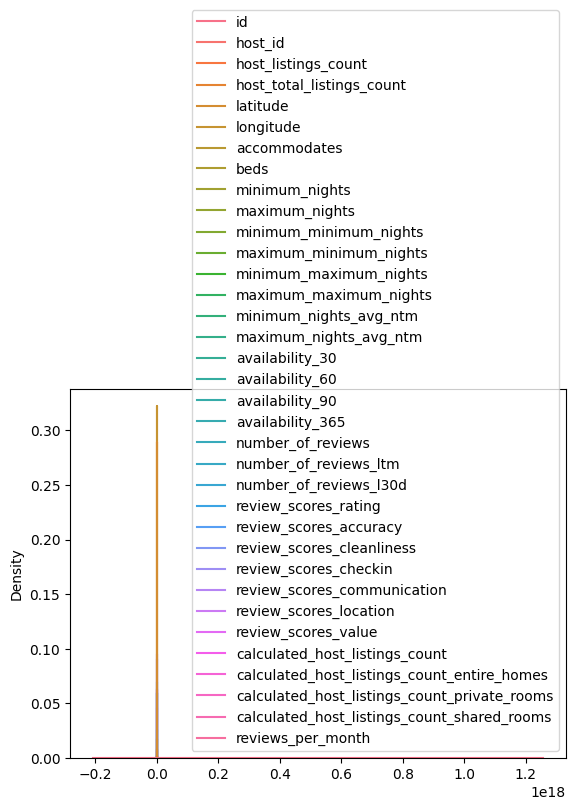

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

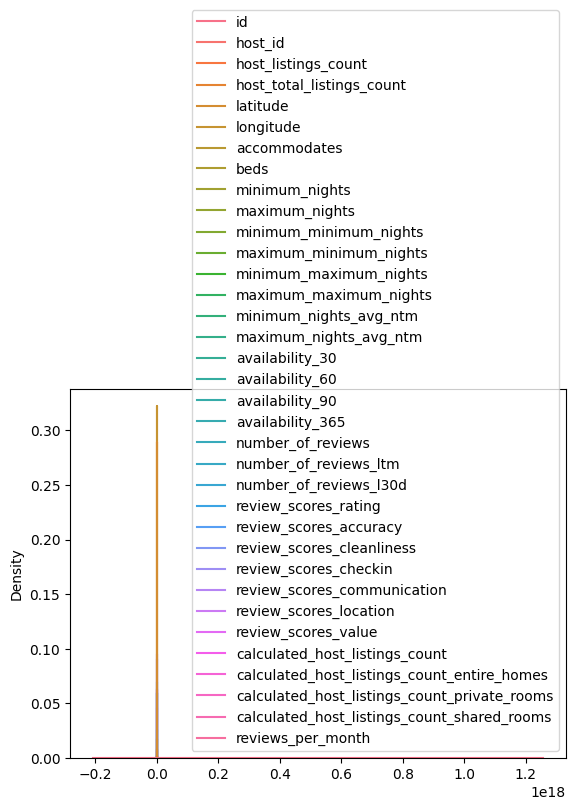

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

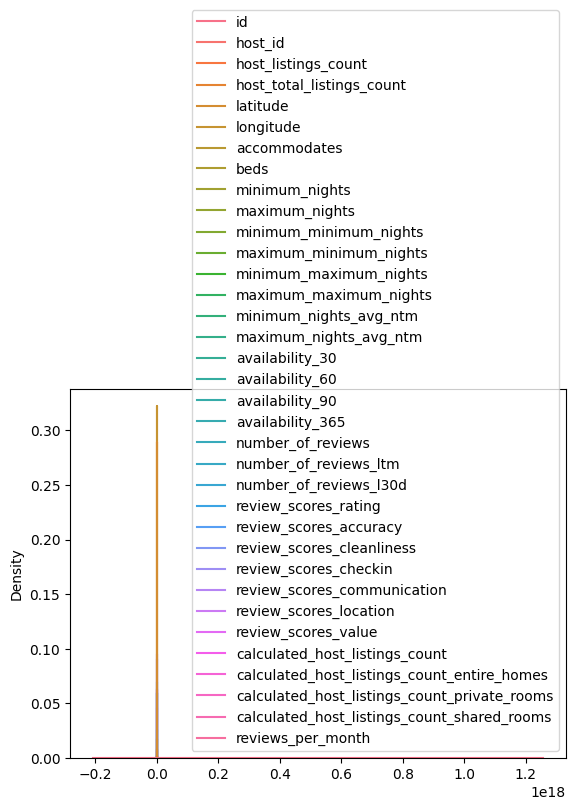

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

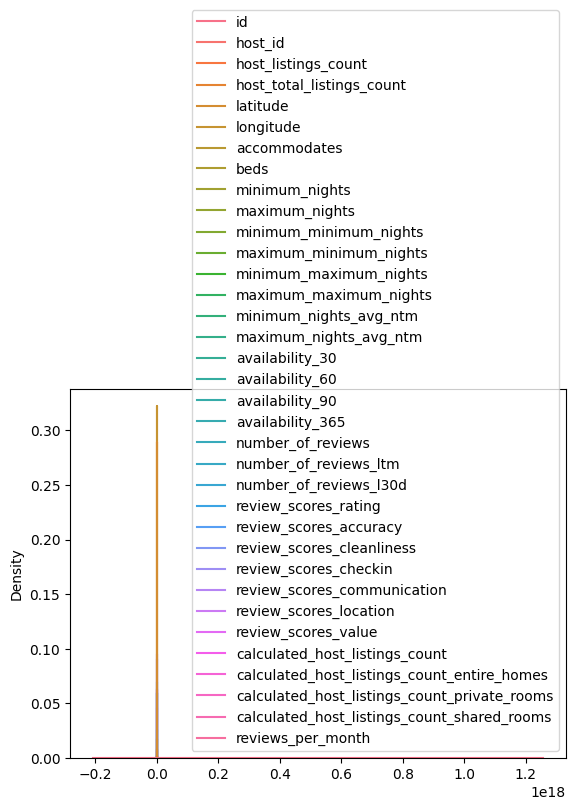

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

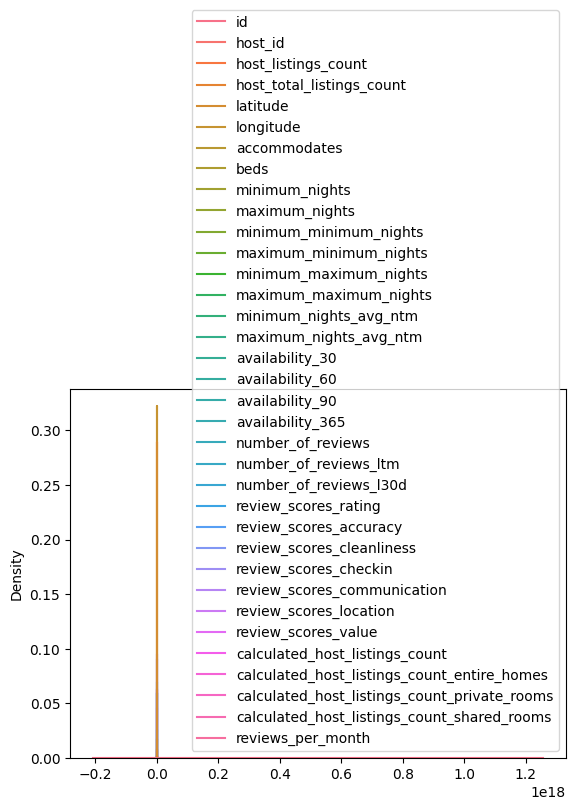

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

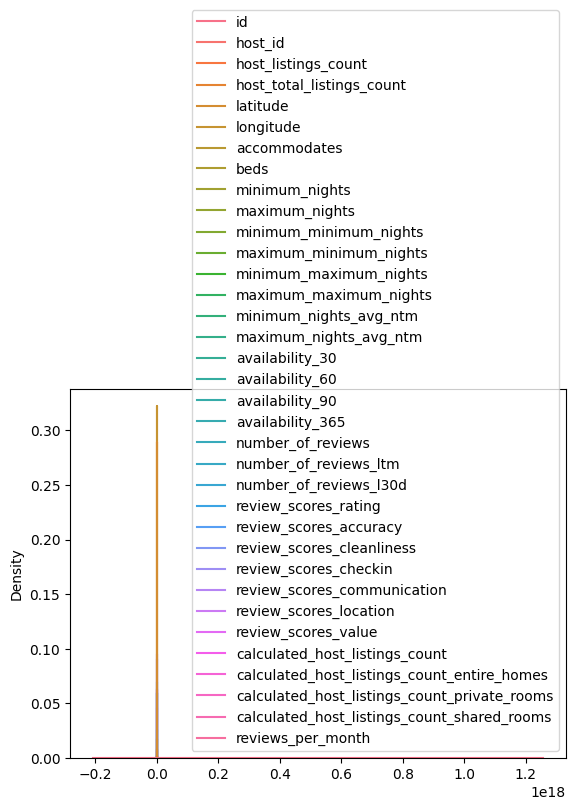

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

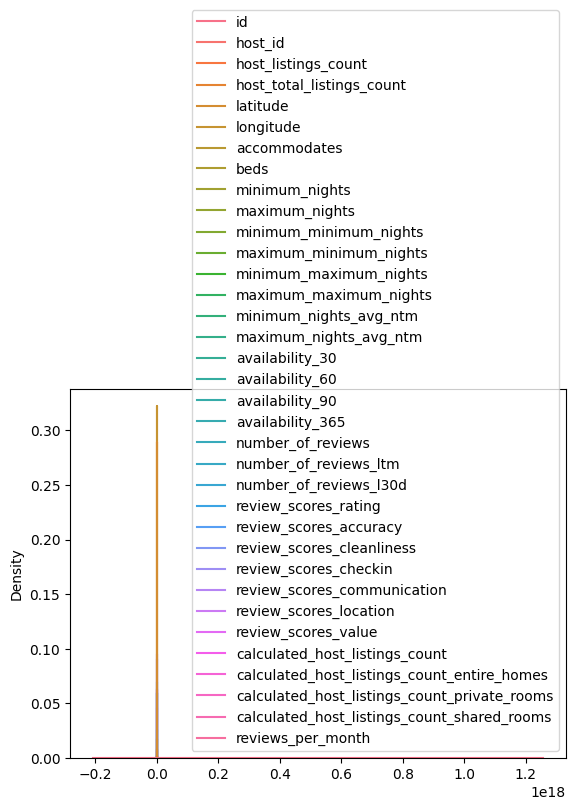

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

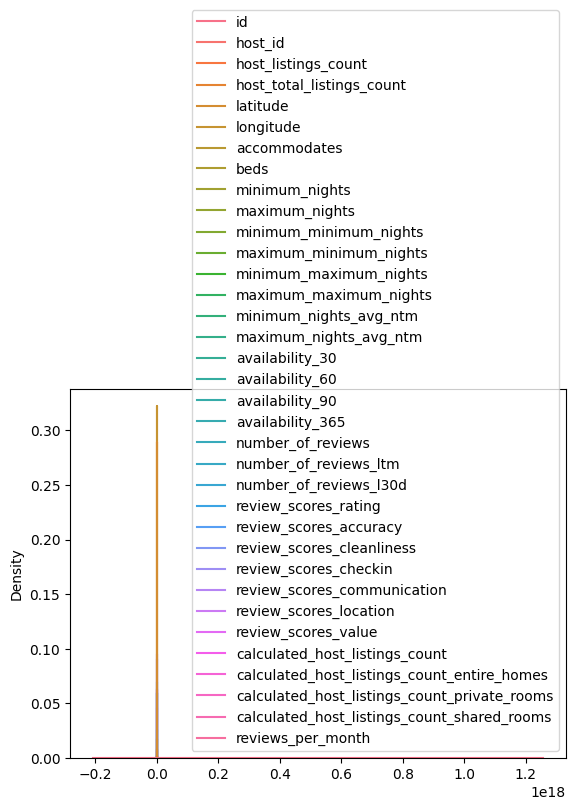

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

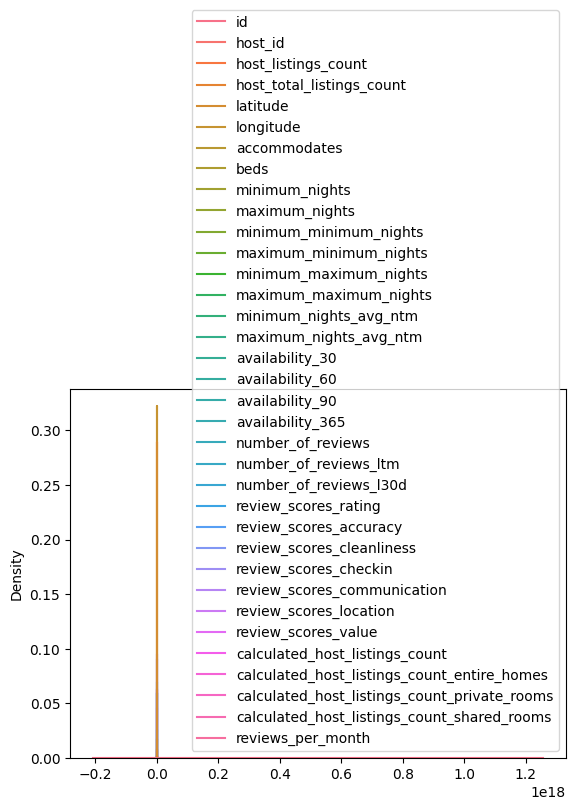

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

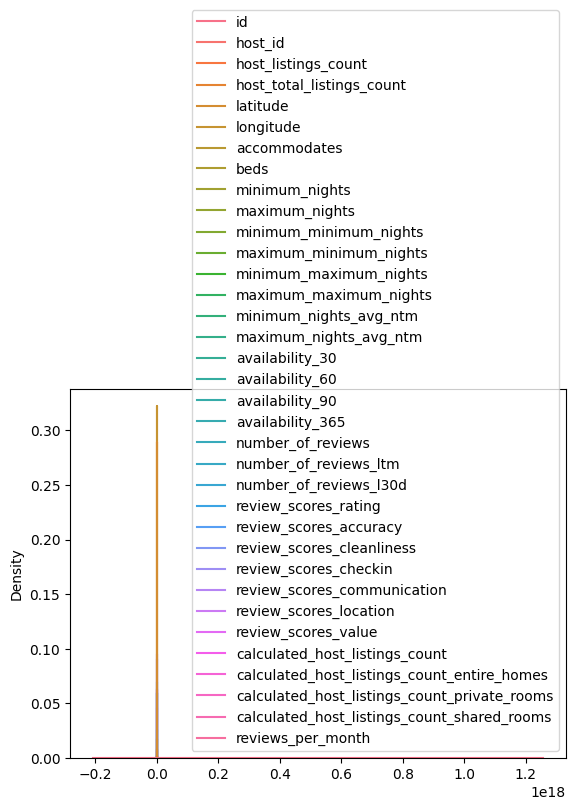

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

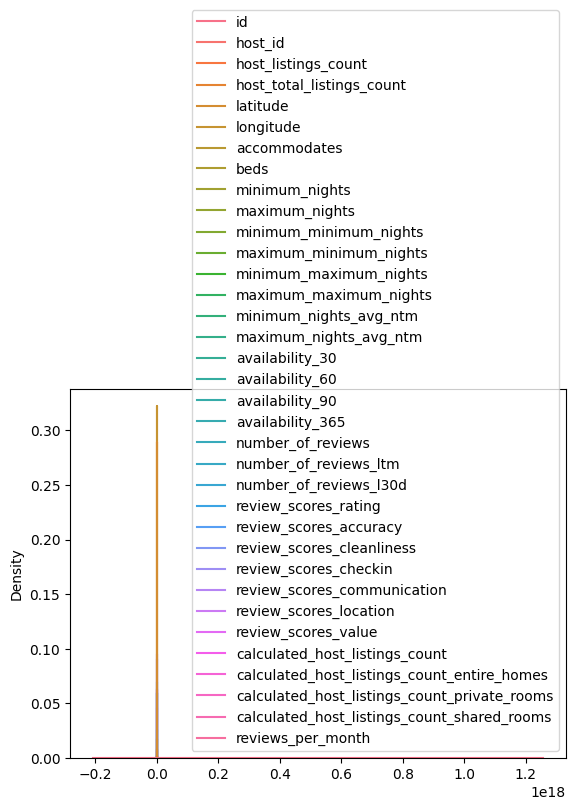

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

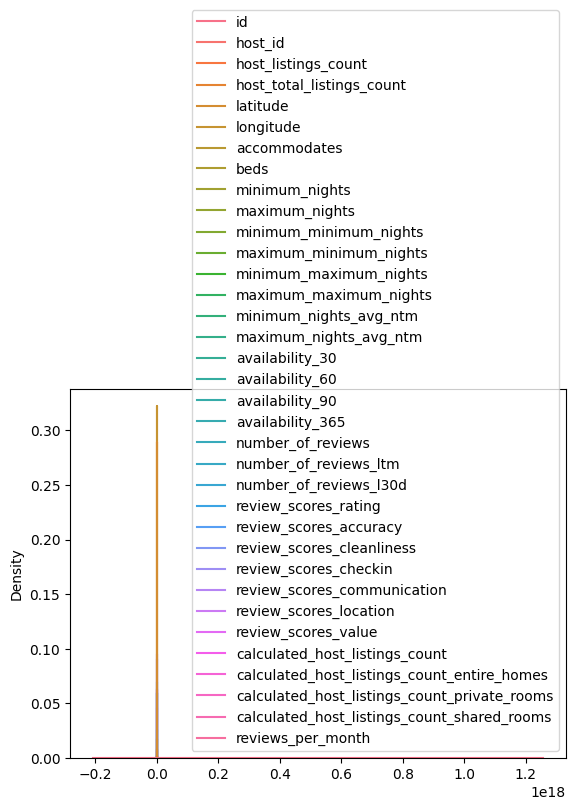

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

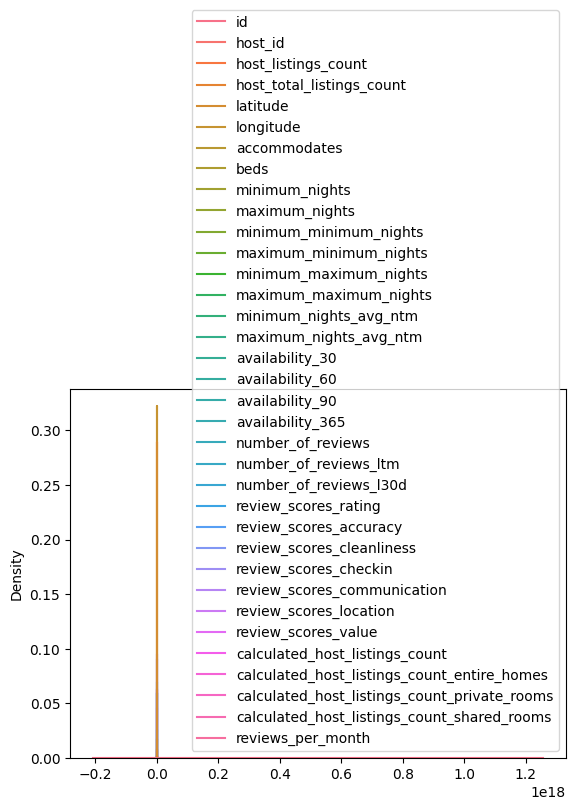

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

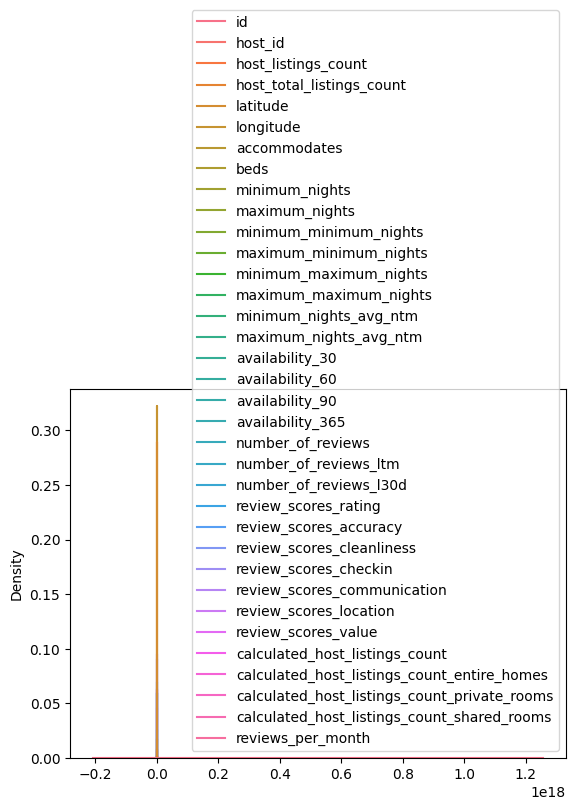

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

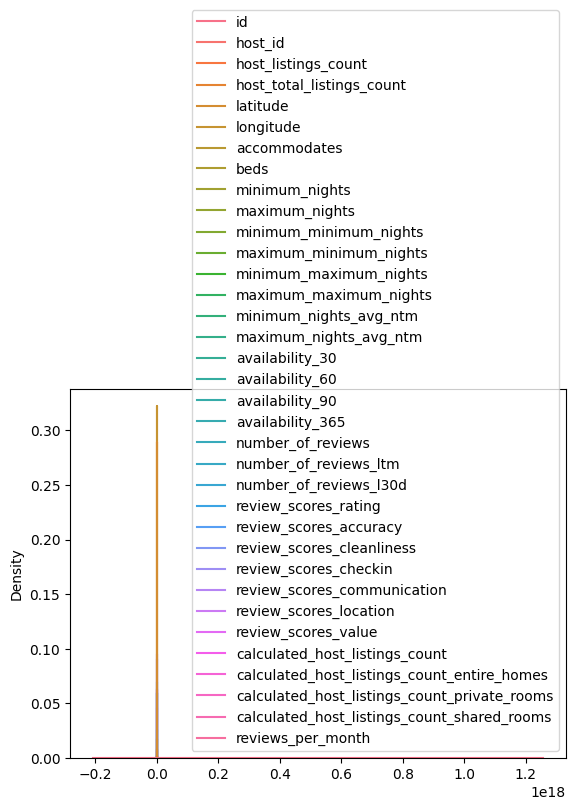

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

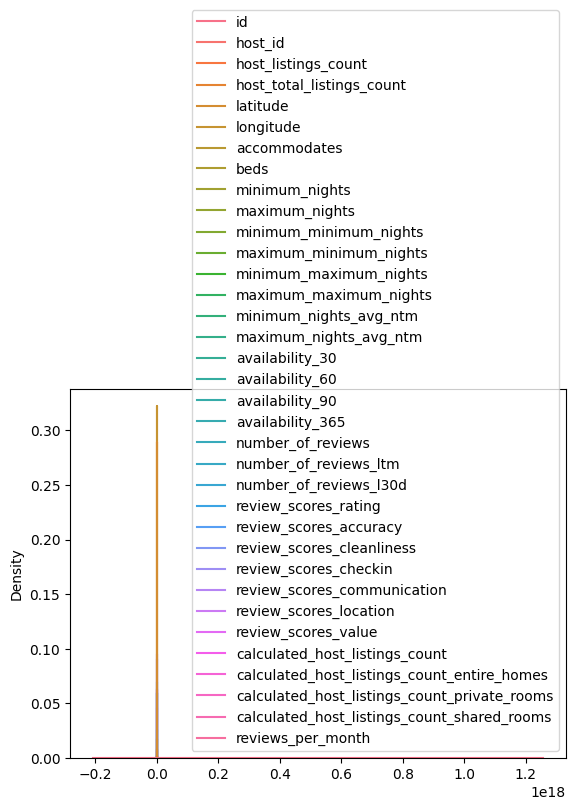

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

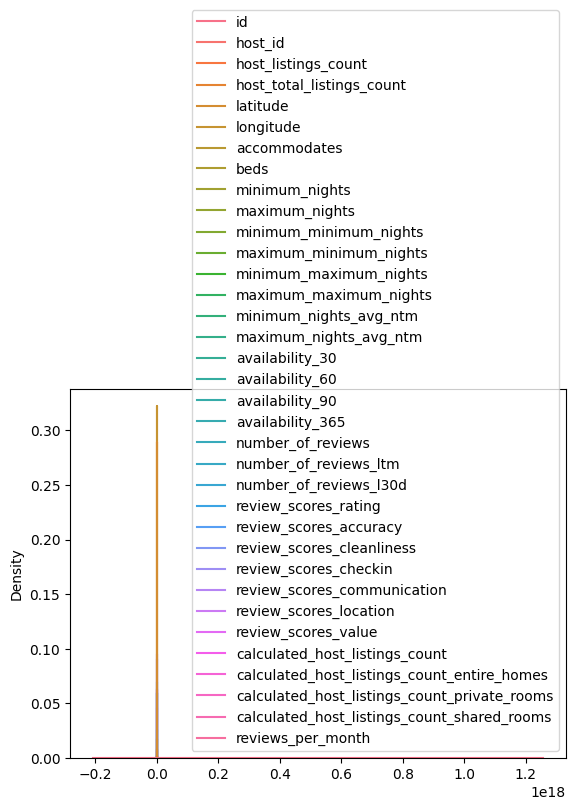

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

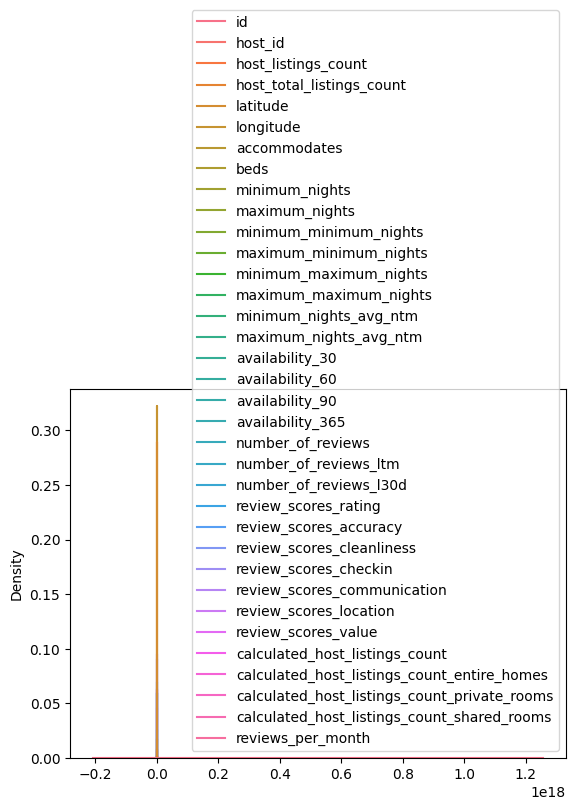

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

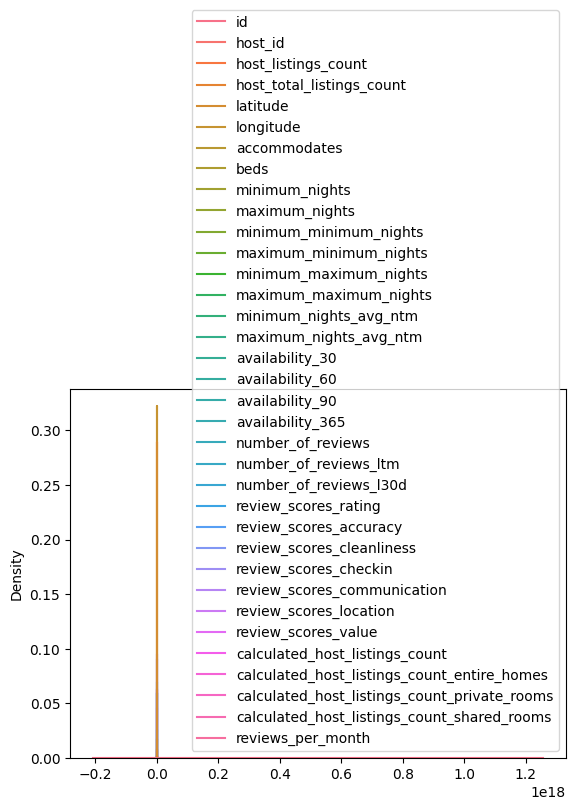

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

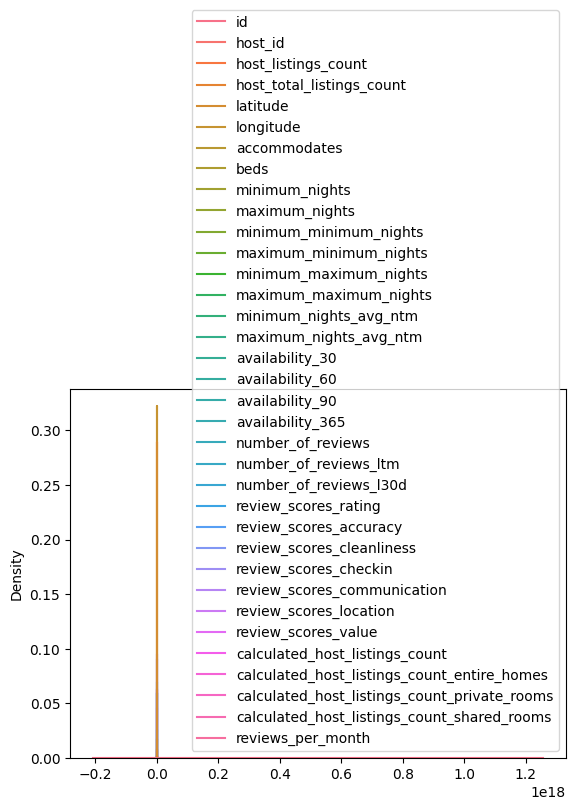

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

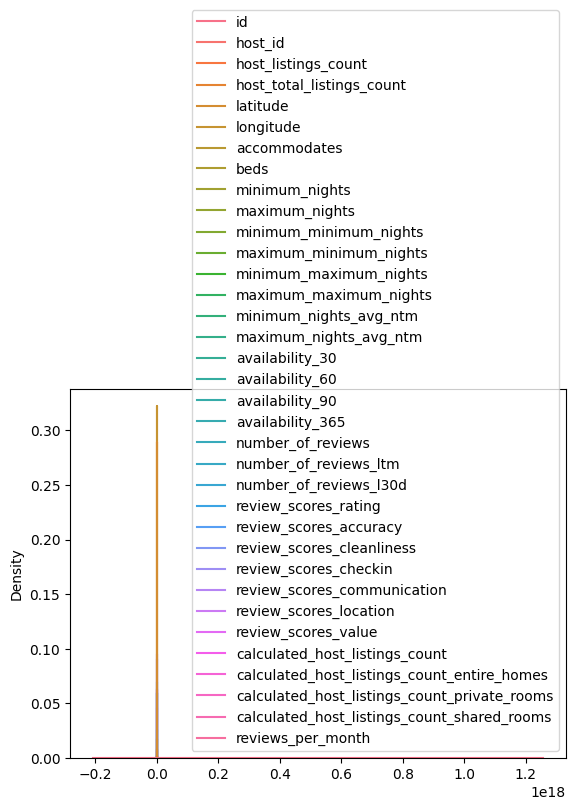

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

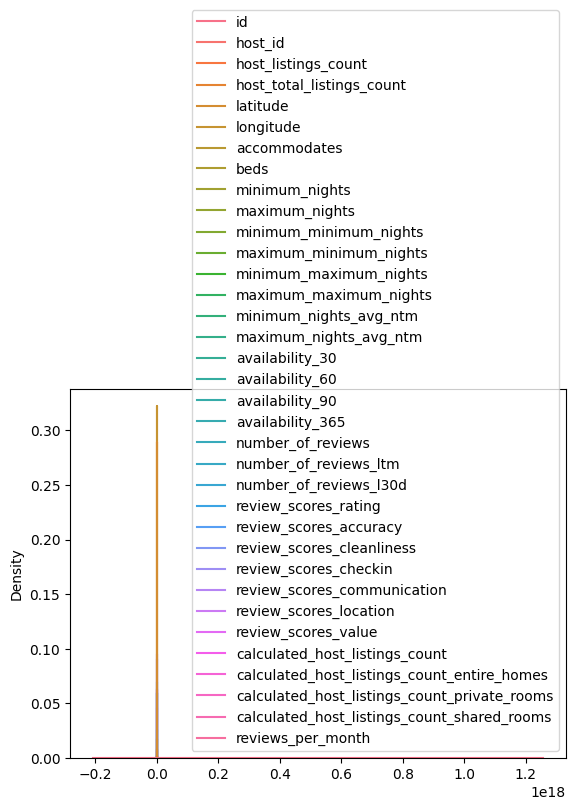

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

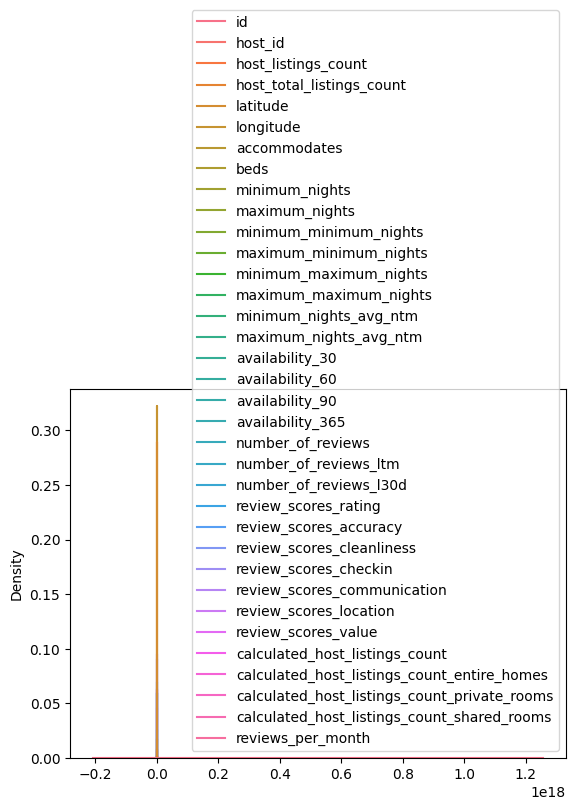

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

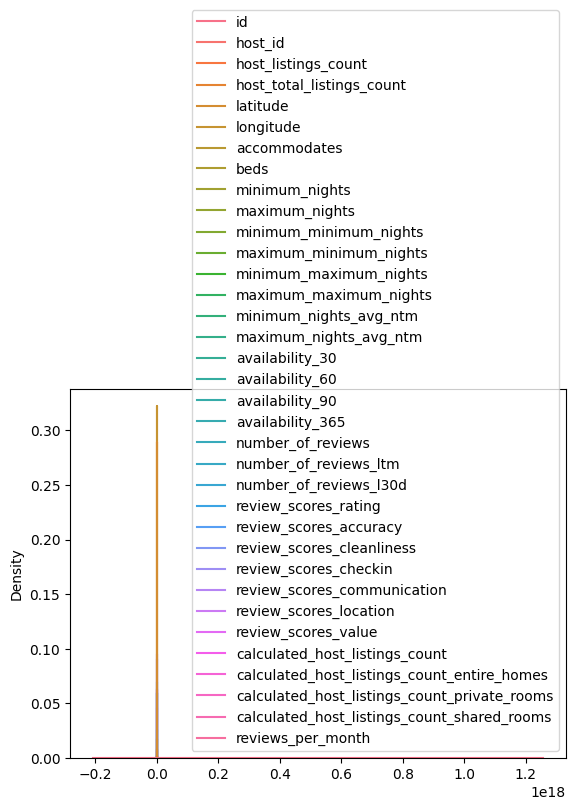

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

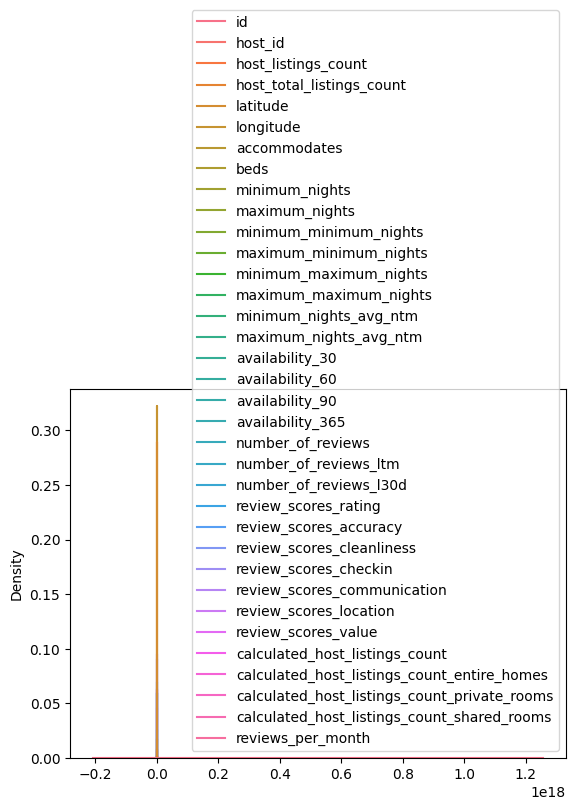

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

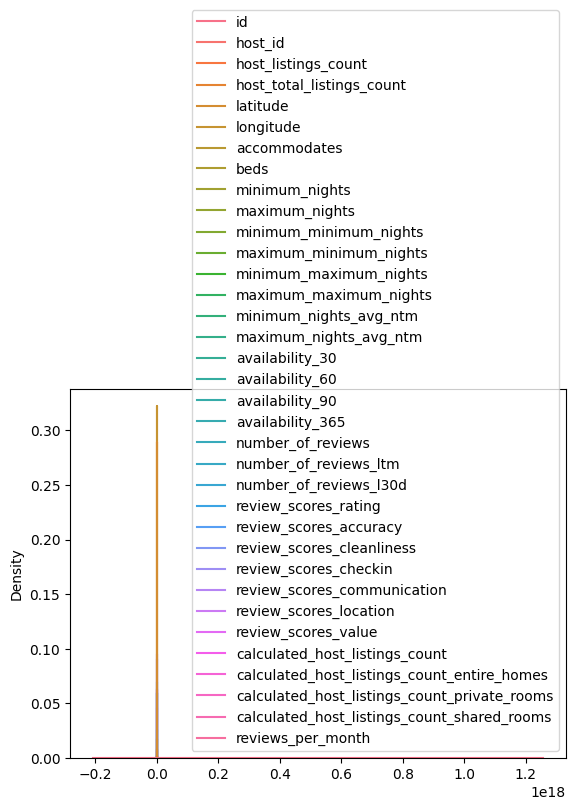

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

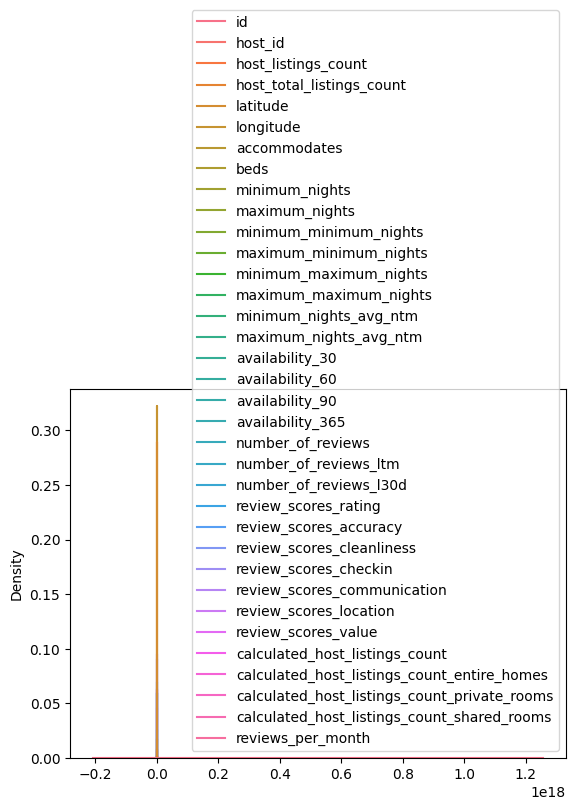

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

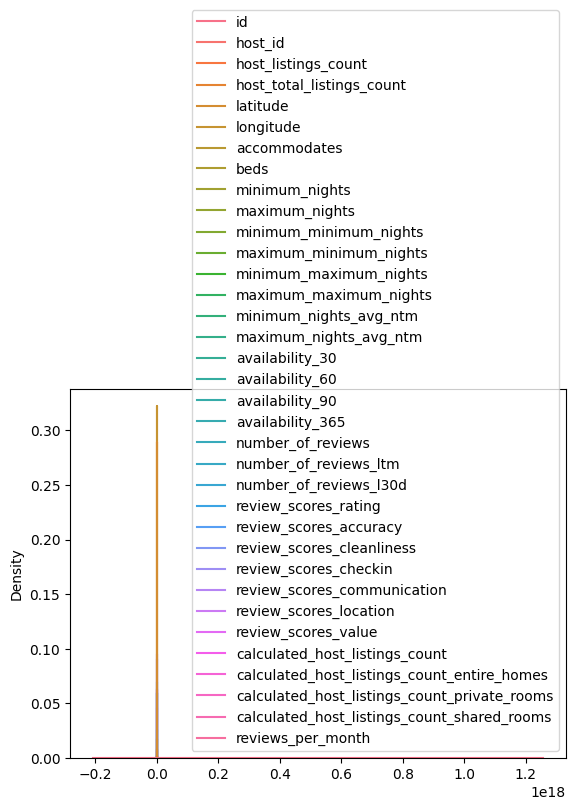

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

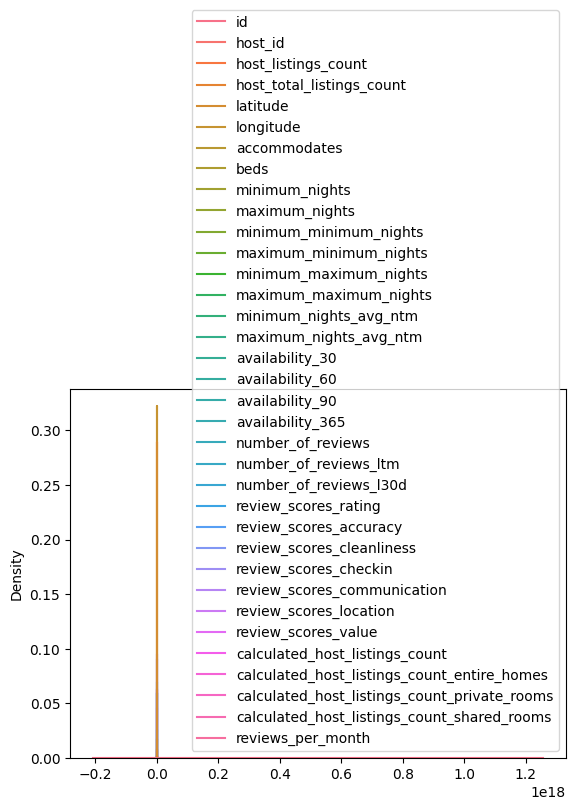

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

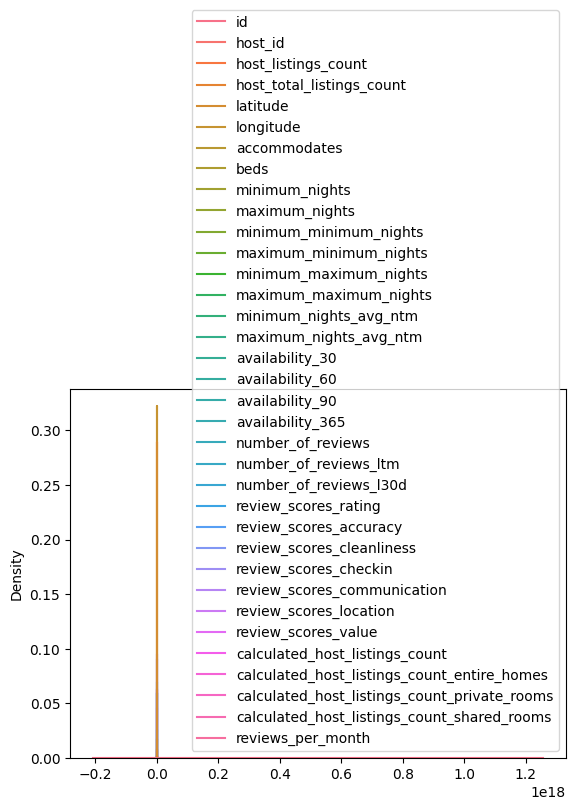

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

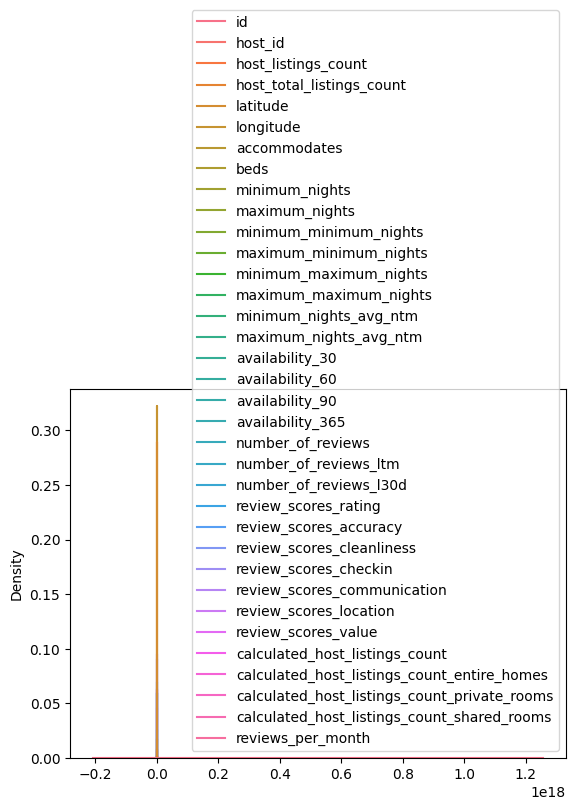

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

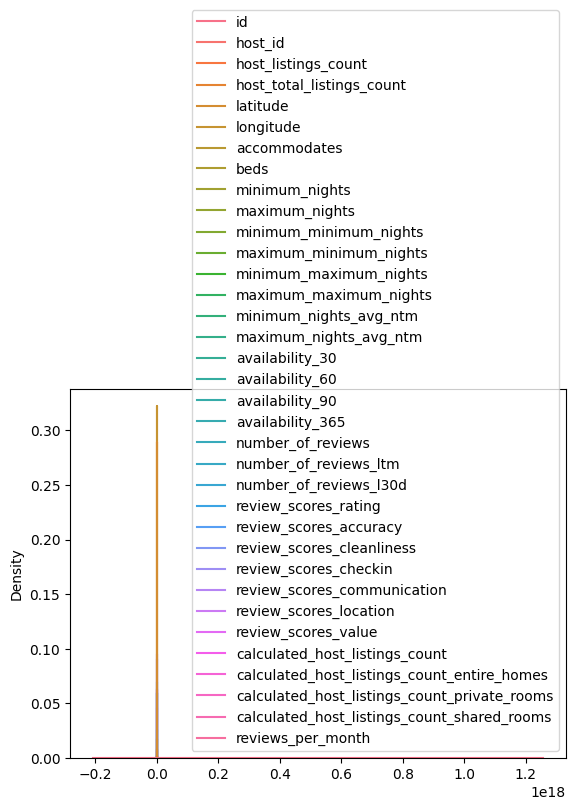

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

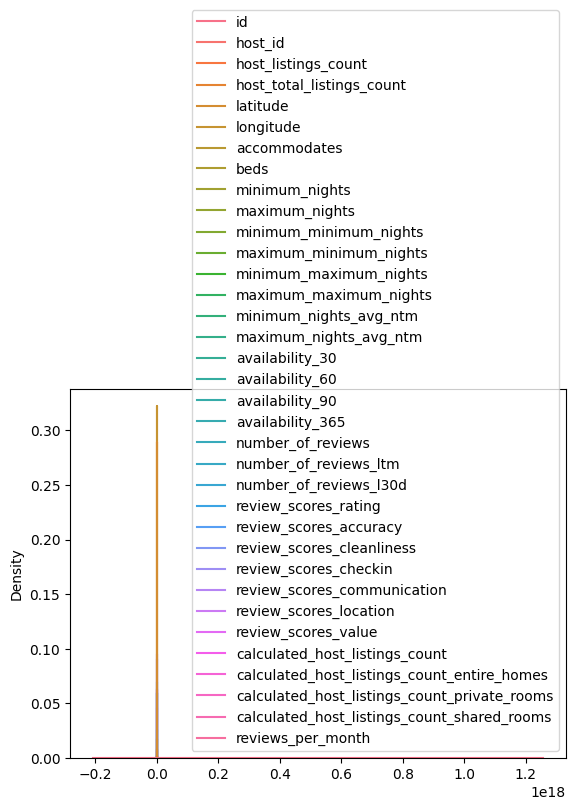

In [36]:
plt.figure(figsize=(5,5))
for i in num_cols:
    sns.kdeplot(data=combined)
    print('\n')
    plt.show()

In [ ]:
sns.histplot(data=combined, x='id', bins=30,hue='host_since', multiple='stack')
plt.show() 

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/distributions.py:269: PerformanceWarning: DataFrame is highly fragmen

In [ ]:
combined.head()

In [ ]:
combined.duplicated()

In [ ]:
combined.duplicated('id')

In [ ]:
combined.head()

In [ ]:
combined.sort_values(['host_since','id'],ascending=False)

In [ ]:
combined.isnull().notnull()/len('combined*100')

In [ ]:
combined.drop('host_since',inplace=True,axis=1)

In [ ]:
combined.head()

In [ ]:
combined.drop('host_location',inplace=False,axis=1)

In [ ]:
combined.head()